In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Loading the dataset
df = pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
X = df.drop(columns=['price'])  # Dropping the target variable 'price' from the features
y = df['price']                 # Setting the target variable 'price'

original_df = df.copy(deep=True)  # Making deep copy of original dataframe to preserve it for later use

#Checking the info of all the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [4]:
#Checking number of unique rows in each feature
df.nunique().sort_values()

guestroom             2
basement              2
mainroad              2
hotwaterheating       2
airconditioning       2
prefarea              2
furnishingstatus      3
bathrooms             4
parking               4
stories               4
bedrooms              6
price               219
area                284
dtype: int64

In [5]:
# Numerical features
nf = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

# Categorical features
cf = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

# Display the feature groups
print("\n\033[1mNumerical Features:\033[0m")
print(nf)

print("\n\033[1mCategorical Features:\033[0m")
print(cf)

print(
    "\n\033[1mInference:\033[0m "
    "The Dataset has {} numerical & {} categorical features."
    .format(len(nf), len(cf))
)


Numerical Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical Features:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Inference: The Dataset has 5 numerical & 7 categorical features.


In [6]:
display(df.describe)

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

Text(0, 0.5, 'Frequency')

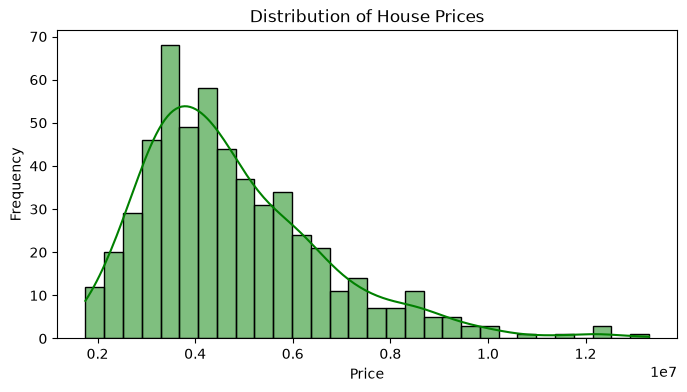

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.histplot(
    df["price"],
    color="g",
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")


# This graph shows the relation between house prices and their frequency distribution

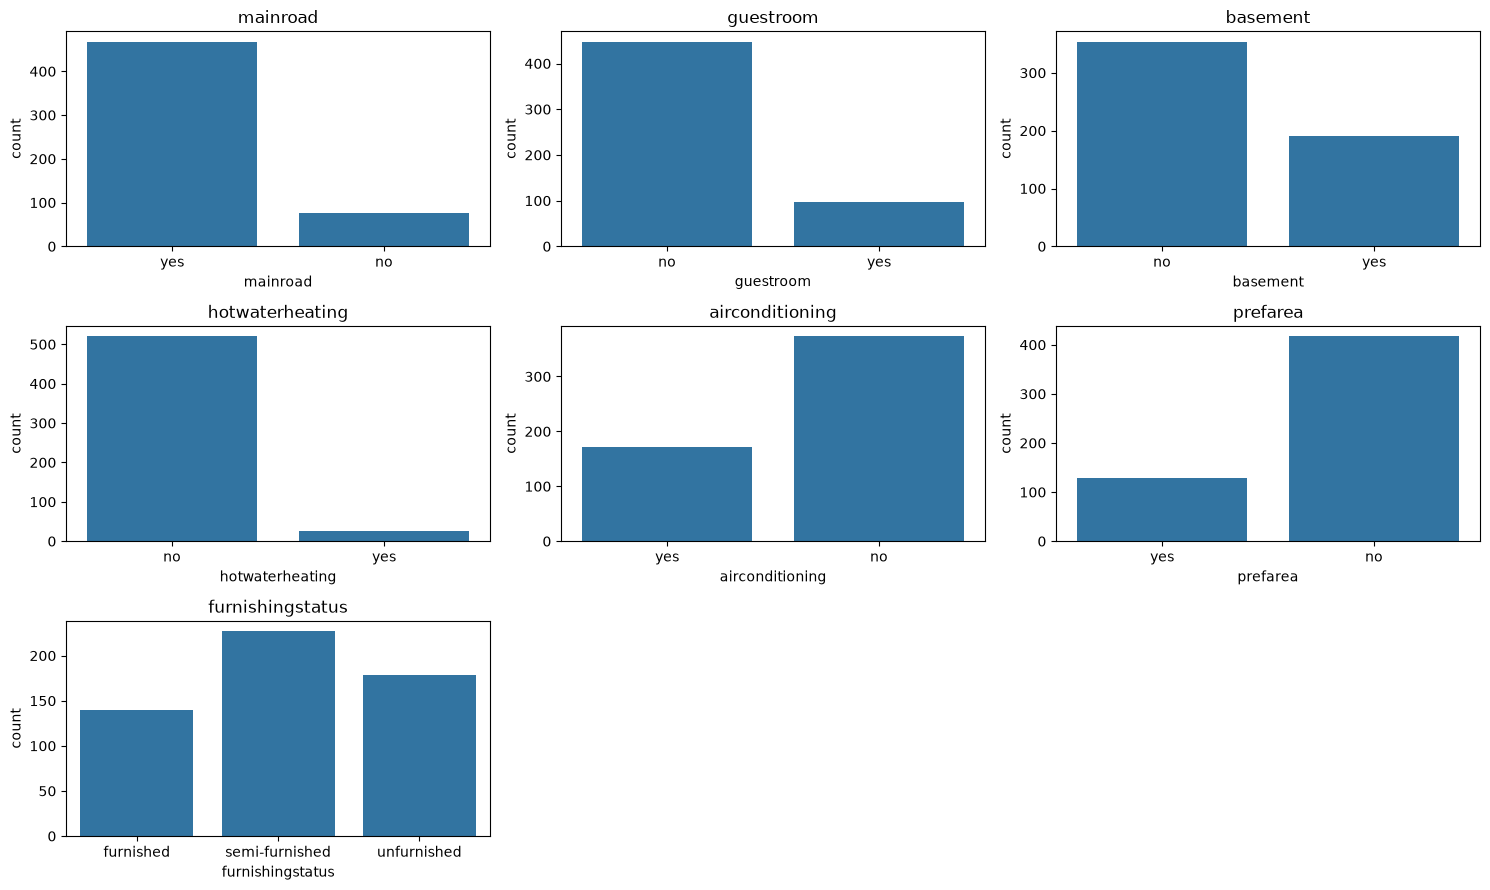

In [8]:
import math

n = 3                               # numbers of columns per row

rows = math.ceil(len(cf)/n)         # 7 / 3 = 2.33 = 3

plt.figure(figsize=(15,3* rows))    # ( width, height)

for i, feature in enumerate(cf):
    plt.subplot(rows,n,i+1)         # (number_of_rows, number_of_columns, position)
    sns.countplot(x=feature, data=df)
    plt.title(feature)

plt.tight_layout()

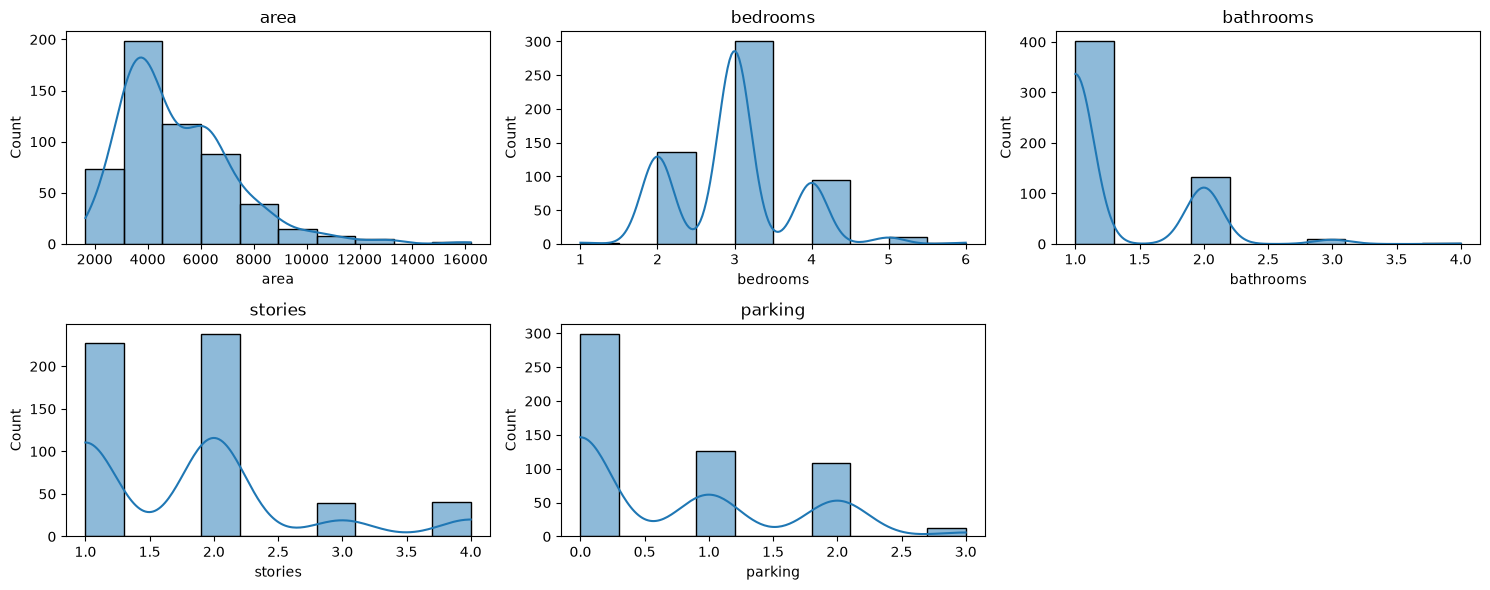

In [9]:
n = 3
rows = math.ceil(len(nf) / n)       # 5 / 3 = 

# Distribution plots
plt.figure(figsize=(15, 3 * rows))

for i, feature in enumerate(nf):
    plt.subplot(rows, n, i + 1)

    # Bins - Into how many intervals/buckets  divide the values (how many blocks to make)
    # kde  - This adds a KDE (Kernel Density Estimate) curve on top of the histogram.
    sns.histplot(df[feature], bins=10, kde=True)

    plt.title(feature)

plt.tight_layout()

# Histogram → shows the distribution/shape of the data.

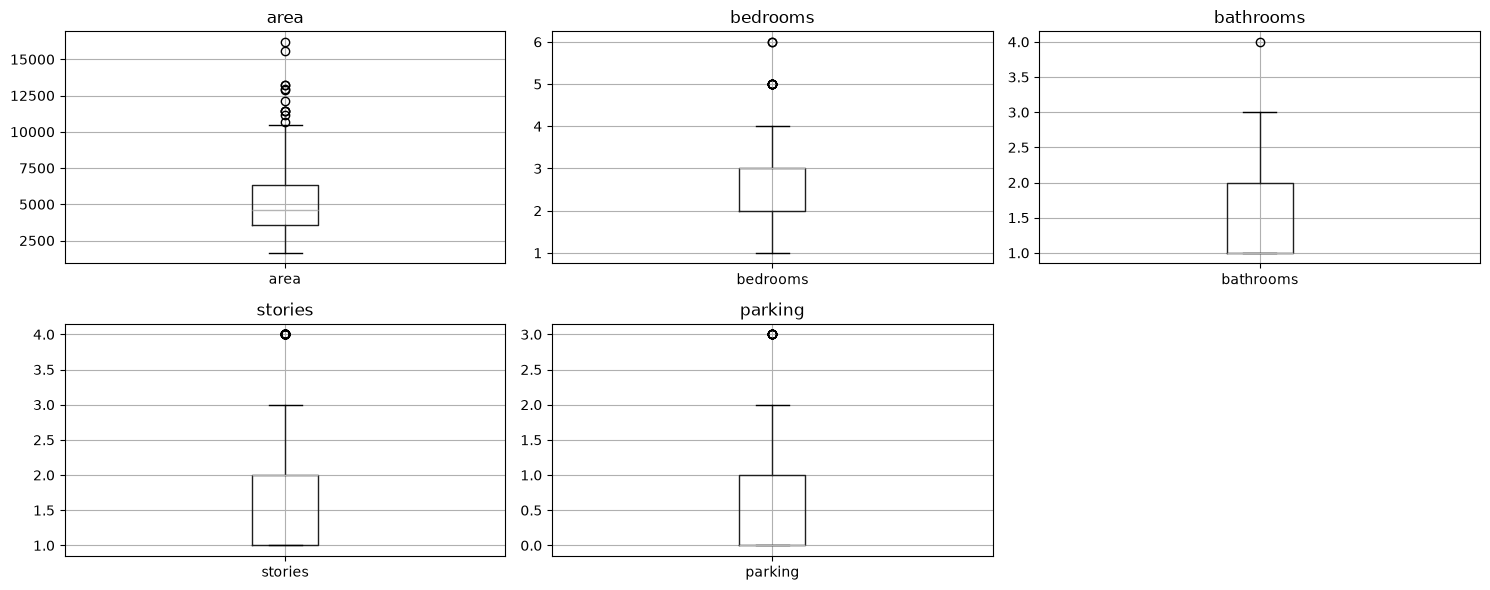

In [10]:
# Boxplots
plt.figure(figsize=(15, 3 * rows))

for i, feature in enumerate(nf):
    plt.subplot(rows, n, i + 1)
    df.boxplot(column=feature)

    plt.title(feature)
plt.tight_layout()

# Box plot → shows the spread, median, quartiles, and possible outliers.

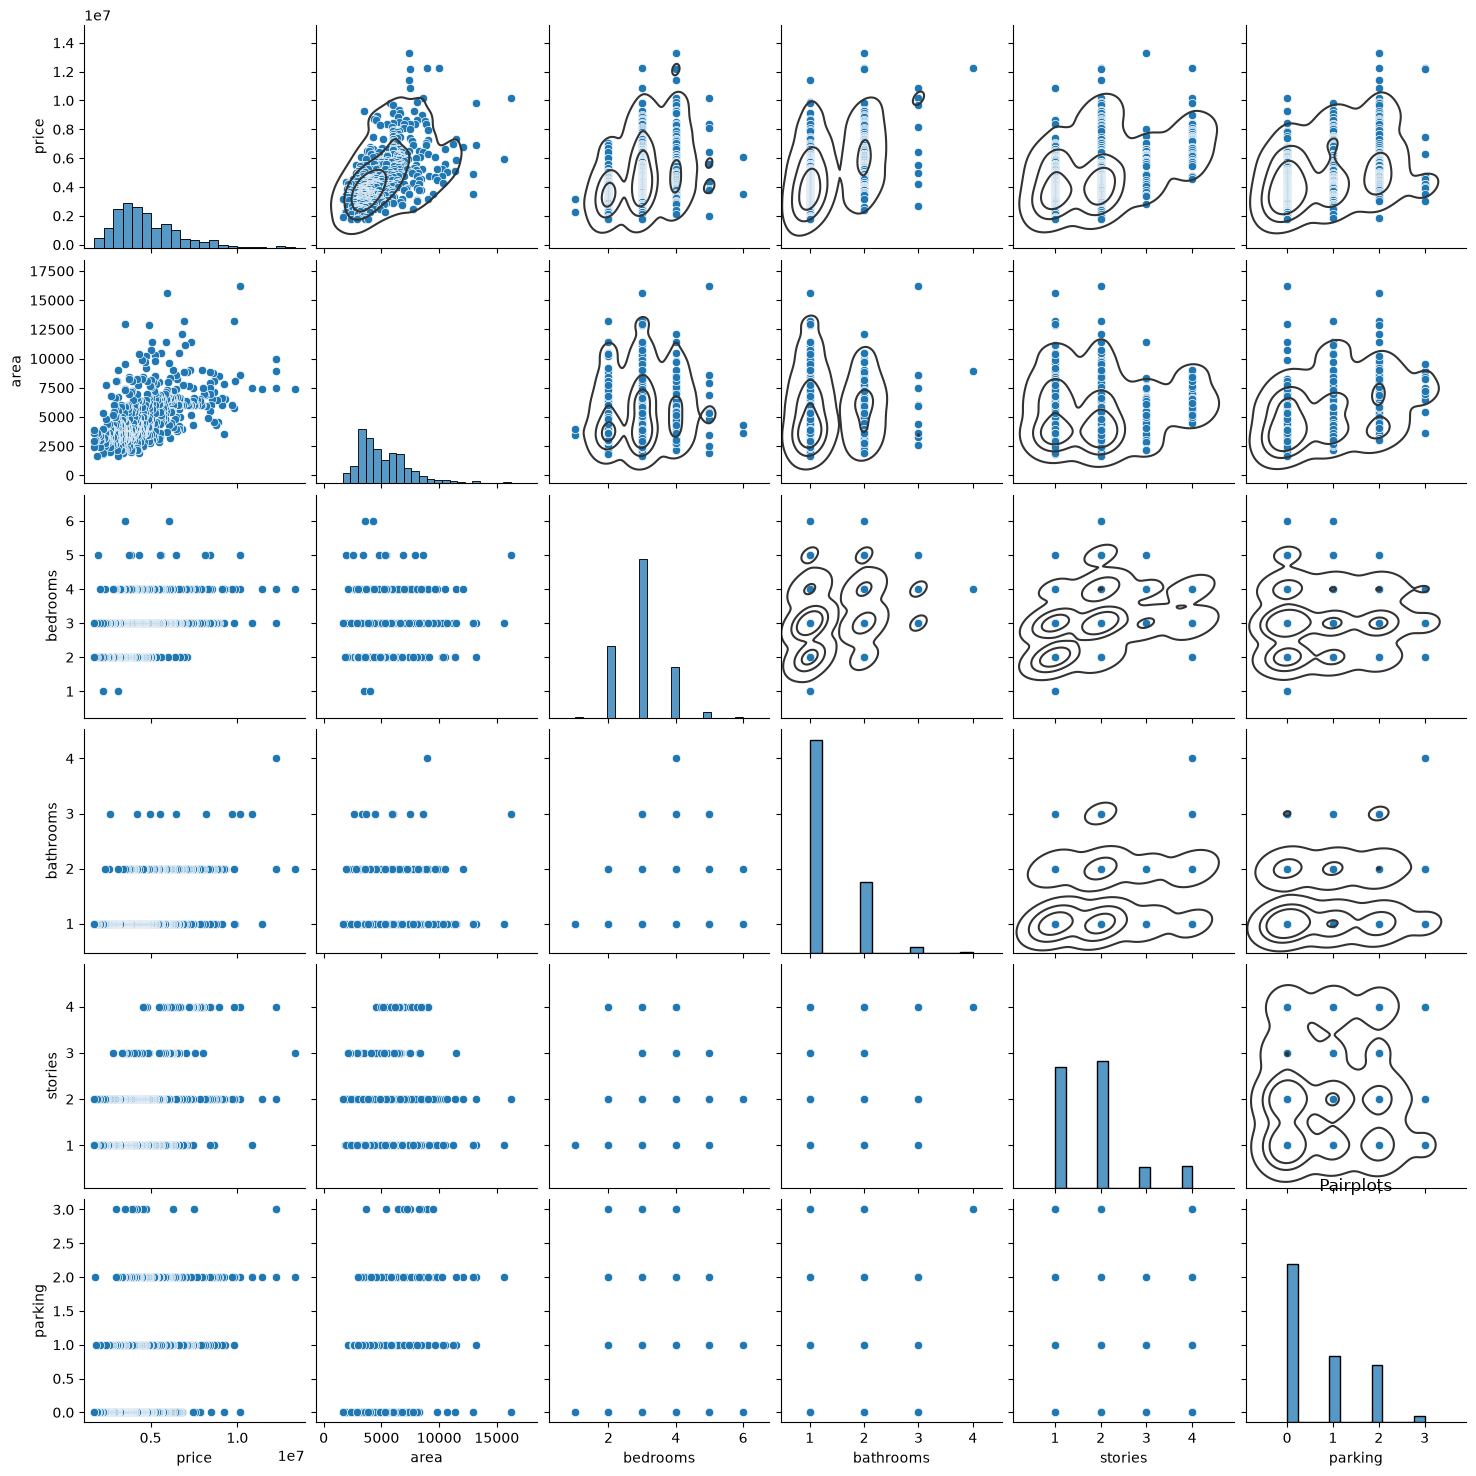

In [11]:
# creates a grid of plots comparing every numerical column with every other numerical column
g = sns.pairplot(df)

plt.title('Pairplots')

g.map_upper(sns.kdeplot, levels=4, color=".2")

In [12]:
#Removal of any Duplicate rows (if any)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count}")

df.drop_duplicates(inplace=True)

print(f"Rows after removing duplicates: {df.shape[0]}")

Duplicate rows found: 0
Rows after removing duplicates: 545


In [13]:
# checking how many null values each column has, and then calculating the percentage of missing values for each column.
nvc = pd.DataFrame(df.isnull().sum().sort_values(), columns=['Total Null Values'])
nvc['Percentage'] = round(
    nvc['Total Null Values'] / df.shape[0] * 100,
    2
)
print(nvc)

                  Total Null Values  Percentage
price                             0         0.0
area                              0         0.0
bedrooms                          0         0.0
bathrooms                         0         0.0
stories                           0         0.0
mainroad                          0         0.0
guestroom                         0         0.0
basement                          0         0.0
hotwaterheating                   0         0.0
airconditioning                   0         0.0
parking                           0         0.0
prefarea                          0         0.0
furnishingstatus                  0         0.0


In [14]:
# This is the categorical encoding step preprocessing. The goal is to convert the categorical text values (yes/no, furnished/etc.) 
# into numerical values that ML models can work with.

df3 = df.copy()  # df3 → preprocessing/encoded version


# These columns have only two categories.
# Binary categorical features → 0/1 (no  → 0 yes → 1)
binary_features = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

# pd.get_dummies() converts categories into numerical representation.
# dtype=int tells Pandas: Store the dummy values as integers.
for feature in binary_features:
    df3[feature] = pd.get_dummies(df3[feature], drop_first=True, dtype=int)

# furnishingstatus → dummy variables
df3 = pd.get_dummies(df3, columns=['furnishingstatus'], drop_first=True, dtype=int)

print(df3.shape)

(545, 14)


In [15]:
for feature in nf:
    Q1 = df3[feature].quantile(0.25)
    Q3 = df3[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df3[
        (df3[feature] < lower) |
        (df3[feature] > upper)
    ]

    print(f"{feature}: {len(outliers)} outliers")
    print(outliers[[feature, 'price']].sort_values(feature))

area: 12 outliers
      area     price
191  10700   5040000
64   11175   7000000
186  11410   5110000
56   11440   7343000
129  11460   5873000
69   12090   6790000
211  12900   4900000
403  12944   3500000
10   13200   9800000
66   13200   6930000
125  15600   5943000
7    16200  10150000
bedrooms: 12 outliers
     bedrooms     price
7           5  10150000
28          5   8400000
34          5   8120000
89          5   6440000
143         5   5600000
152         5   5565000
271         5   4340000
340         5   3850000
536         5   1960000
356         5   3773000
112         6   6083000
395         6   3500000
bathrooms: 1 outliers
   bathrooms     price
1          4  12250000
stories: 41 outliers
     stories     price
1          4  12250000
6          4  10150000
9          4   9800000
17         4   8960000
26         4   8463000
30         4   8400000
31         4   8400000
35         4   8080940
37         4   7980000
38         4   7962500
39         4   7910000
41        

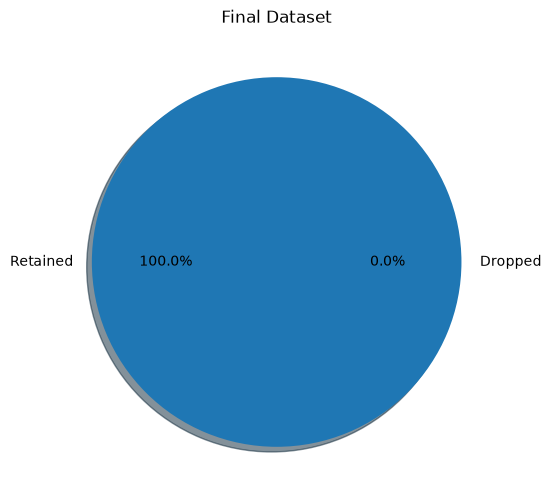


Inference: After preprocessing, 0 samples were dropped, while retaining 100.0% of the data.


In [16]:
# Final Dataset size after preprocessing

df = df3.copy()

# Replace '-' with '_'
df.columns = [i.replace('-', '_') for i in df.columns]

retained = df.shape[0]
dropped = original_df.shape[0] - retained

plt.figure(figsize=(6, 6))

plt.pie(
    [retained, dropped],
    labels=['Retained', 'Dropped'],
    counterclock=False,
    autopct='%1.1f%%',
    shadow=True
)

plt.title('Final Dataset')

plt.show()

print(
    f'\n\033[1mInference:\033[0m '
    f'After preprocessing, {dropped} samples were dropped, '
    f'while retaining {round(retained * 100 / original_df.shape[0], 2)}% of the data.')

In [17]:
from sklearn.model_selection import train_test_split


# Create an empty list to store cleaned column names
m = []

# Loop through all column names in the DataFrame
for i in df.columns.values:

    # Replace spaces in column names with underscores
    m.append(i.replace(' ', '_'))


# Replace the DataFrame's original column names with the cleaned column names stored in m
df.columns = m

# Create the feature dataset by removing the target column 'price'
X = df.drop(["price"], axis=1)

# Create the target variable
Y = df["price"]

# train_size=0.8  → 80% of the data is used for training
# test_size=0.2   → 20% of the data is used for testing
# random_state=100 → keeps the split reproducible
Train_X, Test_X, Train_Y, Test_Y = train_test_split(X,Y,
    train_size=0.8,
    test_size=0.2,
    random_state=100
)


# Reset the index of the training features
# drop=True prevents the old index from becoming a new column
Train_X = Train_X.reset_index(drop=True)

# Reset the index of the testing features
Test_X = Test_X.reset_index(drop=True)

# Reset the index of the training target
Train_Y = Train_Y.reset_index(drop=True)

# Reset the index of the testing target
Test_Y = Test_Y.reset_index(drop=True)


# Display the shape of the original, training, and testing datasets
#
# X.shape       → number of rows and features in the original feature set
# Y.shape       → number of rows in the target
# Train_X.shape → training features
# Train_Y.shape → training target
# Test_X.shape  → testing features
# Test_Y.shape  → testing target
print(
    'Original set  ---> ', X.shape, Y.shape,
    '\nTraining set  ---> ', Train_X.shape, Train_Y.shape,
    '\nTesting set   ---> ', Test_X.shape, '', Test_Y.shape
)

Original set  --->  (545, 13) (545,) 
Training set  --->  (436, 13) (436,) 
Testing set   --->  (109, 13)  (109,)


In [18]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]

std = StandardScaler()
print('\033[1mStandardization on Training set'.center(120))

# fit() learns: mean & standard deviation
# transform() then uses those values to standardize the numerical features.
Train_X_std_num = std.fit_transform(
    Train_X[numerical_features]
)

# Convert the standardized NumPy array back into a DataFrameand restore the original numerical column names.
Train_X_std_num = pd.DataFrame(Train_X_std_num, columns=numerical_features)

# Keep categorical features unchanged
categorical_features = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus_semi_furnished',
    'furnishingstatus_unfurnished'
]

# Copy the categorical columns without changing their 0/1 values.
Train_X_cat = Train_X[categorical_features].copy()

# Combine numerical + categorical feature
Train_X_std = pd.concat([Train_X_std_num, Train_X_cat], axis=1)

# Keep the same column order as the original X
Train_X_std = Train_X_std[X.columns]
display(Train_X_std.describe())


print('\n', '\033[1mStandardization on Testing set'.center(120))

Test_X_std_num = std.transform(Test_X[numerical_features])
Test_X_std_num = pd.DataFrame(Test_X_std_num, columns=numerical_features)
Test_X_cat = Test_X[categorical_features].copy()

# Combine numerical + categorical features
Test_X_std = pd.concat([Test_X_std_num, Test_X_cat], axis=1)

# Keep the same column order as the original X
Test_X_std = Test_X_std[X.columns]
display(Test_X_std.describe())



                                          Standardization on Training set                                           


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished
count,4.360000e+02,4.360000e+02,4.360000e+02,4.360000e+02,436.000000,436.000000,436.000000,436.000000,436.000000,4.360000e+02,436.000000,436.000000,436.000000
mean,4.481634e-17,7.639149e-17,-1.201893e-16,9.370690e-17,0.862385,0.172018,0.353211,0.055046,0.300459,-1.222264e-17,0.231651,0.412844,0.327982
std,1.001149e+00,1.001149e+00,1.001149e+00,1.001149e+00,0.344891,0.377830,0.478517,0.228332,0.458984,1.001149e+00,0.422372,0.492911,0.470017
min,-1.540198e+00,-2.665645e+00,-5.798966e-01,-9.290231e-01,0.000000,0.000000,0.000000,0.000000,0.000000,-8.492607e-01,0.000000,0.000000,0.000000
25%,-7.389912e-01,-1.293483e+00,-5.798966e-01,-9.290231e-01,1.000000,0.000000,0.000000,0.000000,0.000000,-8.492607e-01,0.000000,0.000000,0.000000
50%,-2.933591e-01,7.867901e-02,-5.798966e-01,2.055821e-01,1.000000,0.000000,0.000000,0.000000,0.000000,-8.492607e-01,0.000000,0.000000,0.000000
75%,5.932510e-01,7.867901e-02,1.410929e+00,2.055821e-01,1.000000,0.000000,1.000000,0.000000,1.000000,3.114843e-01,0.000000,1.000000,1.000000
max,5.144981e+00,4.195165e+00,5.392582e+00,2.474792e+00,1.000000,1.000000,1.000000,1.000000,1.000000,2.632974e+00,1.000000,1.000000,1.000000



                                            Standardization on Testing set                                           


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi_furnished,furnishingstatus_unfurnished
count,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.00000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,0.012148,0.154211,-0.050227,-0.075467,0.844037,0.201835,0.33945,0.009174,0.376147,-0.220968,0.247706,0.431193,0.321101
std,1.049393,1.053562,1.000642,0.915477,0.364496,0.403224,0.47571,0.095783,0.486655,0.980508,0.433674,0.497530,0.469056
min,-1.626765,-1.293483,-0.579897,-0.929023,0.000000,0.000000,0.00000,0.000000,0.000000,-0.849261,0.000000,0.000000,0.000000
25%,-0.705249,0.078679,-0.579897,-0.929023,1.000000,0.000000,0.00000,0.000000,0.000000,-0.849261,0.000000,0.000000,0.000000
50%,-0.090905,0.078679,-0.579897,0.205582,1.000000,0.000000,0.00000,0.000000,0.000000,-0.849261,0.000000,0.000000,0.000000
75%,0.537402,1.450841,-0.579897,0.205582,1.000000,0.000000,1.00000,0.000000,1.000000,0.311484,0.000000,1.000000,1.000000
max,4.865734,2.823003,3.401756,2.474792,1.000000,1.000000,1.00000,1.000000,1.000000,2.632974,1.000000,1.000000,1.000000


                                       Correlation Matrix                                       


<Axes: >

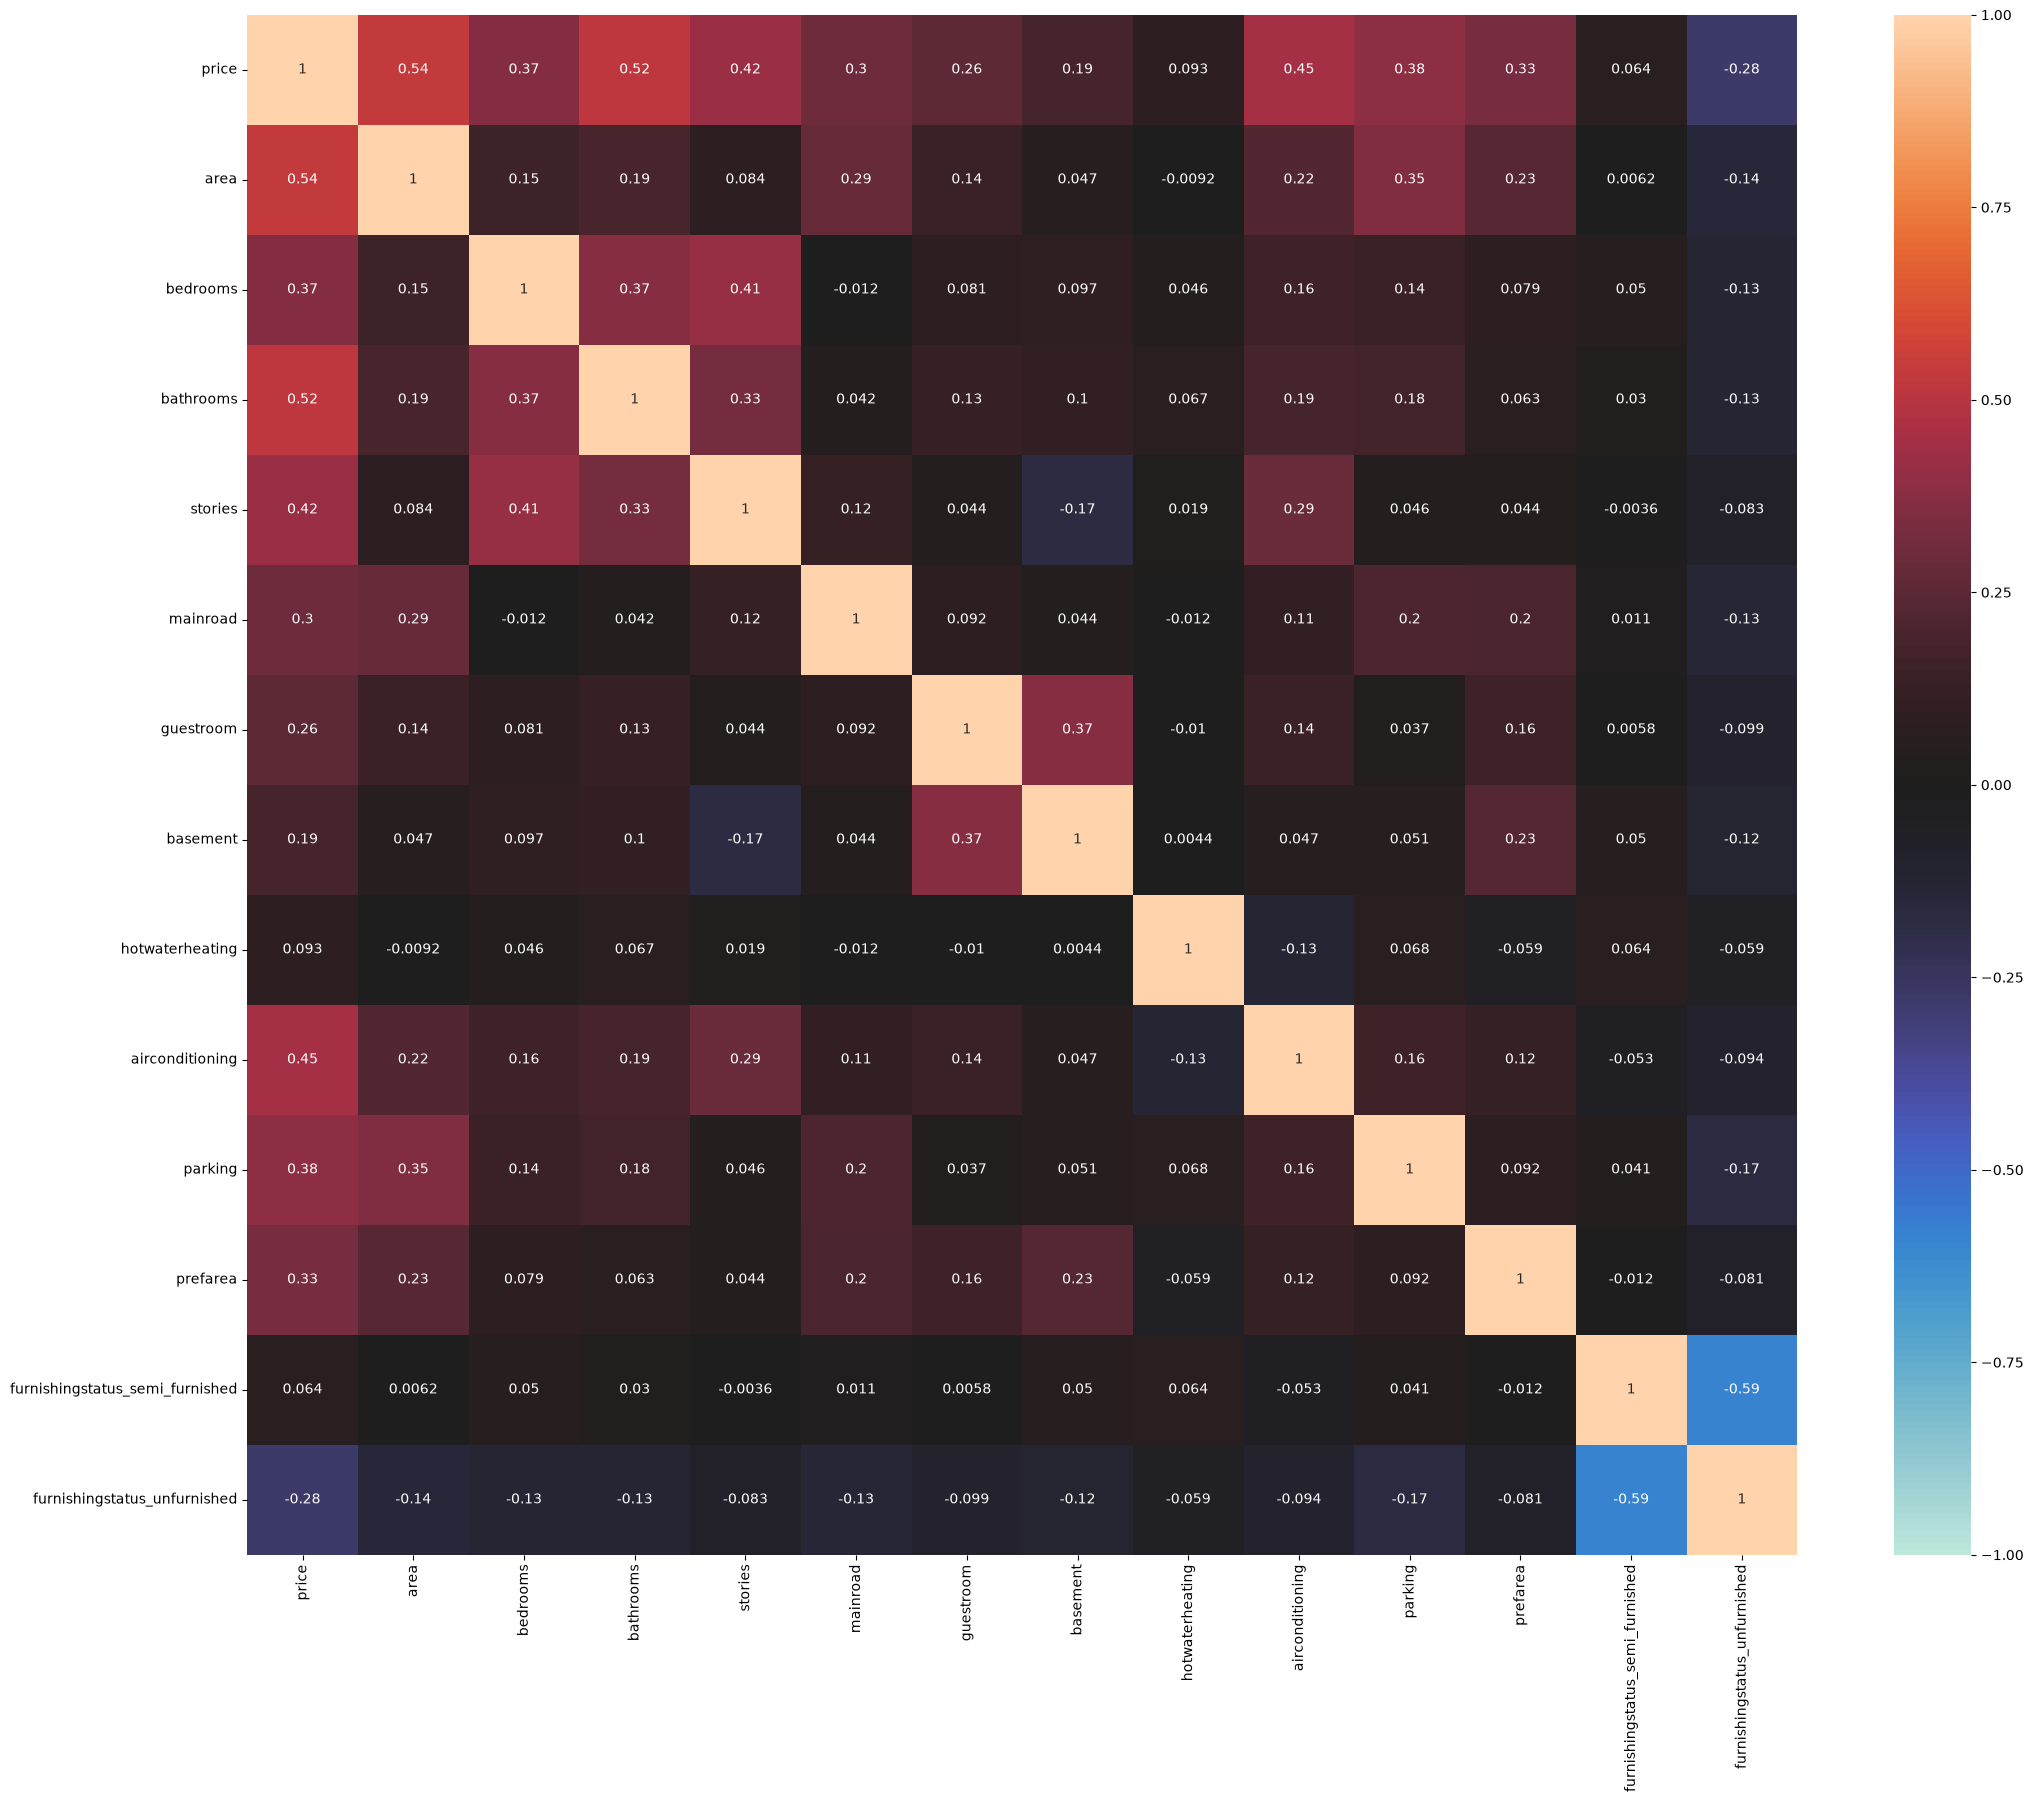

In [19]:
print('\033[1mCorrelation Matrix'.center(100))

plt.figure(figsize=[25,20])

# df.corr() -> It calculates the correlation between every numerical column in DataFrame.
# Correlation tells how strongly two variables have a linear relationship.
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, center=0) 

In [20]:
print('\n\033[1mStrong / Moderate Correlation with Price\033[0m')

price_corr = df.corr()['price'].drop('price')

strong_corr = price_corr[price_corr.abs() >= 0.30].sort_values(ascending=False)

print(strong_corr)


print('\n\033[1mWeak Correlation with Price\033[0m')

weak_corr = price_corr[price_corr.abs() < 0.30].sort_values(ascending=False)

print(weak_corr)


Strong / Moderate Correlation with Price
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
bedrooms           0.366494
prefarea           0.329777
Name: price, dtype: float64

Weak Correlation with Price
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi_furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [21]:
# Testing a Linear Regression model with statsmodels

import statsmodels.formula.api as smf

# Combine standardized training features and training target
Train_xy = pd.concat(
    [Train_X_std, Train_Y.reset_index(drop=True)],
    axis=1
)

# Create the regression formula = target ~ feature1 + feature2 + feature3
# creates a formula like: price ~ area + bedrooms + bathrooms + stories + parking + mainroad + ...
formula = '{} ~ {}'.format(
    'price',
    ' + '.join(i for i in Train_X.columns)
)

print("Formula:", formula)

# Fit the OLS regression model , OLS stands for: Ordinary Least Squares
# It finds the coefficients that minimize the squared diff b/w: actual price and predicted price
API = smf.ols(formula=formula, data=Train_xy).fit()

# Display the statistical summary
API.summary()

Formula: price ~ area + bedrooms + bathrooms + stories + mainroad + guestroom + basement + hotwaterheating + airconditioning + parking + prefarea + furnishingstatus_semi_furnished + furnishingstatus_unfurnished


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     68.41
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           3.51e-95
Time:                        05:53:36   Log-Likelihood:                -6666.8
No. Observations:                 436   AIC:                         1.336e+04
Df Residuals:                     422   BIC:                         1.342e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                        3.877e+06   1.87e+05     20.750      0.000    3.51e+06    4.24e+06
area                             5.231e+05   5.95e+04      8.795      0.000    4.06e+05     6.4e+05
bedrooms                         6.612e+04   6.05e+04      1.093      0.275   -5.28e+04    1.85e+05
bathrooms                        5.713e+05   5.88e+04      9.710      0.000    4.56e+05    6.87e+05
stories                          3.577e+05   6.29e+04      5.687      0.000    2.34e+05    4.81e+05
mainroad                         5.751e+05   1.62e+05      3.545      0.000    2.56e+05    8.94e+05
guestroom                        3.849e+05   1.51e+05      2.555      0.011    8.88e+04    6.81e+05
basement                         2.777e+05   1.24e+05      2.241      0.026    3.41e+04    5.21e+05
hotwaterheating                  8.479e+05   2.32e+05      3.658      0.000    3.92e+05     1.3e+06
airconditioning                  8.451e+05   1.23e+05      6.844      0.000    6.02e+05    1.09e+06
parking                          2.084e+05   5.64e+04      3.693      0.000    9.75e+04    3.19e+05
prefarea                         6.045e+05    1.3e+05      4.667      0.000     3.5e+05    8.59e+05
furnishingstatus_semi_furnished  -1.02e+05   1.32e+05     -0.775      0.439   -3.61e+05    1.57e+05
furnishingstatus_unfurnished    -4.272e+05    1.4e+05     -3.041      0.003   -7.03e+05   -1.51e+05
==============================================================================
Omnibus:                       79.435   Durbin-Watson:                   2.090
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              209.468
Skew:                           0.886   Prob(JB):                     3.27e-46
Kurtosis:                       5.897   Cond. No.                         7.66
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
"""
R-squared
    → How much variation in price the model explains.
    → Your model: 0.678 = 67.8% in training data.
    → NOT "67.8% accuracy".

Adjusted R-squared
    → R² adjusted for the number of predictors.
    → Useful when comparing models with different numbers of features.

F-statistic
    → Tests whether the predictors are jointly useful.
    → Very small Prob(F) → evidence that the overall model
      has predictive/explanatory relationship with price.

coef
    → Estimated effect of a feature while keeping other
      features constant.
    → Numerical features were standardized, so:
         +1 = one standard deviation increase.
    → Binary features:
         0 → 1 category change.

std err
    → Estimated uncertainty of the coefficient.

t
    → Approximately:
         coefficient / standard error

P>|t|
    → Tests whether the coefficient is different from 0.
    → Common rule:
         p < 0.05 → statistically significant
         p >= 0.05 → insufficient evidence of significance
    → This is a statistical convention, not a measure of
      model accuracy.

[0.025, 0.975]
    → 95% confidence interval for the coefficient.

Intercept
    → Predicted price when all standardized numerical features
      are 0 and binary features are 0.
    → Not necessarily a real house.

AIC / BIC
    → Used mainly for comparing statistical models.
    → Lower is generally preferred when comparing models
      fitted to the same data.

Omnibus / Jarque-Bera
    → Tests whether residuals look approximately normal.
    → Your very small p-values indicate residuals are
      not perfectly normally distributed.

Skew
    → Measures asymmetry of residuals.
    → Your value ≈ 0.886 → noticeable right skew.

Kurtosis
    → Measures tail/heaviness of residual distribution.
    → Your value ≈ 5.9 → heavier tails than normal.

Durbin-Watson
    → Checks residual autocorrelation.
    → Around 2 is generally desirable.
    → Yours ≈ 2.09.

Condition Number
    → Helps detect numerical conditioning / multicollinearity
      problems.
    → Yours ≈ 7.66 → no obvious severe issue.
"""

'\nR-squared\n    → How much variation in price the model explains.\n    → Your model: 0.678 = 67.8% in training data.\n    → NOT "67.8% accuracy".\n\nAdjusted R-squared\n    → R² adjusted for the number of predictors.\n    → Useful when comparing models with different numbers of features.\n\nF-statistic\n    → Tests whether the predictors are jointly useful.\n    → Very small Prob(F) → evidence that the overall model\n      has predictive/explanatory relationship with price.\n\ncoef\n    → Estimated effect of a feature while keeping other\n      features constant.\n    → Numerical features were standardized, so:\n         +1 = one standard deviation increase.\n    → Binary features:\n         0 → 1 category change.\n\nstd err\n    → Estimated uncertainty of the coefficient.\n\nt\n    → Approximately:\n         coefficient / standard error\n\nP>|t|\n    → Tests whether the coefficient is different from 0.\n    → Common rule:\n         p < 0.05 → statistically significant\n         p >=

In [23]:
"""
| Information        | What we learned from your model                                                                                |
| ------------------ | -------------------------------------------------------------------------------------------------------------- |
| Observations       | 436 training houses were used                                                                                  |
| Predictors         | 13 features were used to predict price                                                                         |
| R-squared          | 0.678 → model explains about 67.8% of the variation in training prices                                         |
| Adjusted R-squared | 0.668 → similar fit after accounting for the number of features                                                |
| F-statistic        | 68.41 → the predictors are jointly useful for explaining price                                                 |
| Prob(F-statistic)  | 3.51e-95 → very strong statistical evidence that the overall model is not just an intercept-only model         |
| Area               | Positive and statistically significant relationship with price                                                 |
| Bedrooms           | Not statistically significant after accounting for the other features (p=0.275)                                |
| Bathrooms          | Positive and statistically significant relationship                                                            |
| Stories            | Positive and statistically significant relationship                                                            |
| Mainroad           | Houses with mainroad=1 have a positive estimated association with price                                        |
| Guestroom          | Positive statistically significant association                                                                 |
| Basement           | Positive statistically significant association                                                                 |
| Hotwaterheating    | Positive statistically significant association                                                                 |
| Airconditioning    | Positive statistically significant association                                                                 |
| Parking            | Positive statistically significant association                                                                 |
| Prefarea           | Positive statistically significant association                                                                 |
| Semi-furnished     | No strong statistical evidence of a difference from the furnished reference category (p=0.439)                 |
| Unfurnished        | Negative statistically significant association compared with the furnished reference category                  |
| Residual normality | Omnibus/Jarque-Bera indicate residuals are not perfectly normally distributed                                  |
| Residual skewness  | 0.886 → residuals have noticeable right skew                                                                   |
| Residual kurtosis  | 5.897 → heavier tails than a normal distribution                                                               |
| Durbin-Watson      | 2.09 → close to 2, so no obvious first-order residual autocorrelation                                          |
| Condition number   | 7.66 → no obvious severe numerical-conditioning problem                                                        |
| AIC/BIC            | Can be used to compare this model with other statistical models; lower is generally preferred on the same data |
"""

'\n| Information        | What we learned from your model                                                                                |\n| ------------------ | -------------------------------------------------------------------------------------------------------------- |\n| Observations       | 436 training houses were used                                                                                  |\n| Predictors         | 13 features were used to predict price                                                                         |\n| R-squared          | 0.678 → model explains about 67.8% of the variation in training prices                                         |\n| Adjusted R-squared | 0.668 → similar fit after accounting for the number of features                                                |\n| F-statistic        | 68.41 → the predictors are jointly useful for explaining price                                                 |\n| Prob(F-statistic)  | 3.51e-95 → very

'\nHOW TO READ IT\nFind where the red line crosses the green dashed line — that tells you the minimum number of components needed to keep 90% of the information in your data.\nFrom your plot, that crossing happens around PC7 or PC8 — the red line is just under 0.9 at 7 and just over it at 8.\n\nWhy this matters practically: instead of using all 13 original features, you could reduce your dataset to ~8 principal components and still retain ~90% of the meaningful variance \ncutting dimensionality by nearly 40% while losing very little information. This is useful for speeding up models, reducing overfitting,\nand simplifying visualization, at the cost of some interpretability (each PC is a combination of original features, not a single one).\n'

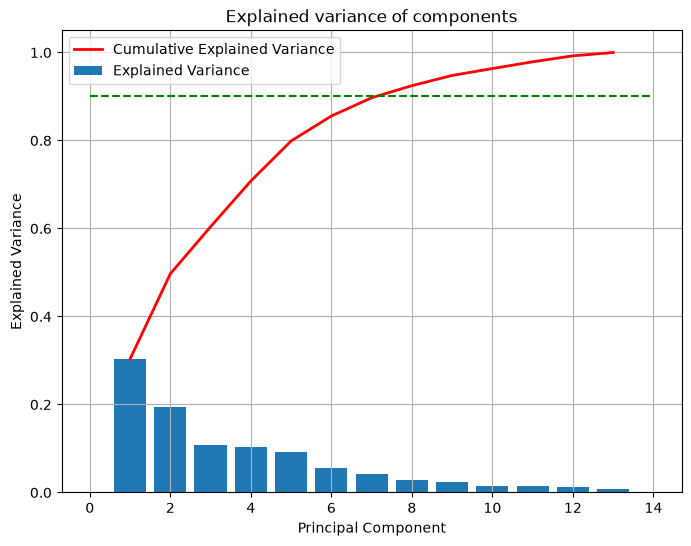

In [24]:
# PCA is a dimensionality reduction technique.
from sklearn.decomposition import PCA

# PCA() - Creates a PCA object.PCA initially considers all available components. We have 13 input features, so we'll get 13 principal components
# .fit(Train_X_std) -PCA looks at your training data and learns directions that capture the maximum variance.
# The first component captures the most variance.
# The second captures the next most, and so on.
pca = PCA().fit(Train_X_std)

fig, ax = plt.subplots(figsize=(8,6))

# pca.n_components_ tells you how many components PCA found, we have 13 So: range(1, 13 + 1)
x_values = range(1, pca.n_components_+1)

# pca.explained_variance_ratio_ - It tells you the proportion of total variance explained by each component.
ax.bar(x_values, pca.explained_variance_ratio_, lw=2, label='Explained Variance')
ax.plot(x_values, np.cumsum(pca.explained_variance_ratio_), lw=2, label='Cumulative Explained Variance', color='red')

# This draws a horizontal dashed line at: 0.9 = 90%, basically "how many principal components are needed to retain around 90% of the variance."
plt.plot([0,pca.n_components_+1],[0.9,0.9],'g--')
ax.set_title('Explained variance of components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance')
plt.legend()
plt.grid()

"""
HOW TO READ IT
Find where the red line crosses the green dashed line — that tells you the minimum number of components needed to keep 90% of the information in your data.
From your plot, that crossing happens around PC7 or PC8 — the red line is just under 0.9 at 7 and just over it at 8.

Why this matters practically: instead of using all 13 original features, you could reduce your dataset to ~8 principal components and still retain ~90% of the meaningful variance 
cutting dimensionality by nearly 40% while losing very little information. This is useful for speeding up models, reducing overfitting,
and simplifying visualization, at the cost of some interpretability (each PC is a combination of original features, not a single one).
"""

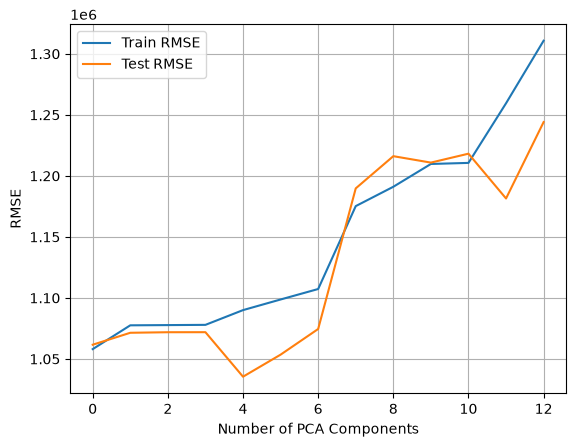

In [29]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# Trr - Training RMSE, Tss - Testing RMSE, Every time we train a model, one value gets added. 
Trr=[]; Tss=[]; 

components = []

# num of features, dataset has 14 columns inclduing price so 14-1 = 13, m =13
m=df.shape[1]-1

for n_components in range(m, 0, -1):
    pca = PCA(n_components=n_components)

    # fit PCA learns the principal directions from the training data. 
    # transfors It converts original features into PCA components.   
    Train_X_pca = pca.fit_transform(Train_X_std)
    Test_X_pca = pca.transform(Test_X_std)

    # create and fit linear regression model
    LR = LinearRegression()
    LR.fit(Train_X_pca, Train_Y)    

    train_pred = LR.predict(Train_X_pca)
    test_pred = LR.predict(Test_X_pca)

    # mean_squared_error(Train_Y, pred1) calculates MSE. Then: np.sqrt() converts MSE into RMSE.
    # RMSE - tells roughly how far predictions are from actual prices, in the same unit as price.
    train_rmse = np.sqrt(mean_squared_error(Train_Y, train_pred))
    test_rmse = np.sqrt( mean_squared_error(Test_Y, test_pred))

    components.append(n_components)
    Trr.append(train_rmse)
    Tss.append(test_rmse)

plt.plot(Trr, label='Train RMSE')
plt.plot(Tss, label='Test RMSE')
plt.xlabel('Number of PCA Components')
plt.ylabel('RMSE')
plt.legend()
plt.grid()

In [ ]:
# Recursive Feature Elimination from scikit-learn,RFE is a feature-selection technique.
# Its goal is: Remove the less useful features and keep the most useful ones.
from sklearn.feature_selection import RFE

lm = LinearRegression()
# shape[1] gives the num of column so 13 - 5 = 8, keeping 8 featrues and eliminating 5
rfe = RFE(lm, n_features_to_select=Train_X_std.shape[1]-5)         
rfe = rfe.fit(Train_X_std, Train_Y)

LR = LinearRegression()
LR.fit(Train_X_std.loc[:,rfe.support_], Train_Y)

# rfe.support_ is a Boolean array telling which features RFE selected.
pred1 = LR.predict(Train_X_std.loc[:,rfe.support_])
pred2 = LR.predict(Test_X_std.loc[:,rfe.support_])

print("Train RMSE: ", np.sqrt(mean_squared_error(Train_Y, pred1)))
print("Test RMSE: ", np.sqrt(mean_squared_error(Test_Y, pred2)))

selected_features = Train_X_std.columns[rfe.support_]

print("Selected Features:")
print(selected_features.tolist())

ranking = pd.DataFrame({
    'Feature': Train_X_std.columns,
    'Ranking': rfe.ranking_,
    'Selected': rfe.support_
})

print(ranking.sort_values('Ranking'))


Train RMSE:  1157913.544527793
Test RMSE:  1242410.2302524822
Selected Features:
['area', 'bathrooms', 'mainroad', 'hotwaterheating', 'airconditioning', 'prefarea']
                            Feature  Ranking  Selected
0                              area        1      True
2                         bathrooms        1      True
7                   hotwaterheating        1      True
4                          mainroad        1      True
10                         prefarea        1      True
8                   airconditioning        1      True
5                         guestroom        2     False
12     furnishingstatus_unfurnished        3     False
3                           stories        4     False
6                          basement        5     False
9                           parking        6     False
11  furnishingstatus_semi_furnished        7     False
1                          bedrooms        8     False


<<<----------------------------------- Evaluating Multiple Linear Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 523109.95193922   66116.64775464  571341.38886287  357741.5667533
  575124.37673332  384897.45745525  277737.762919    847855.38320599
  845077.64065092  208377.3327589   604469.53802638 -101979.02160813
 -427196.80240469]
The Intercept of the Regresion Model was found to be  3877047.001651504


--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.6781789392869301
Residual Sum of Squares (RSS) on Training set  ---> 488093560627881.44
Mean Squared Error (MSE) on Training set       ---> 1119480643641.93
Root Mean Squared Error (RMSE) on Training set ---> 1058055.1231584912

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.6806539407870678
Residual Sum of Squares (RSS) on Training set  ---> 122856712931890.0
Mean Squared Error (

C:\Users\piyus\AppData\Local\Temp\ipykernel_2356\2541320826.py:68: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Train_Y - pred1))


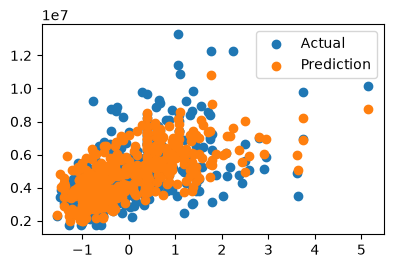

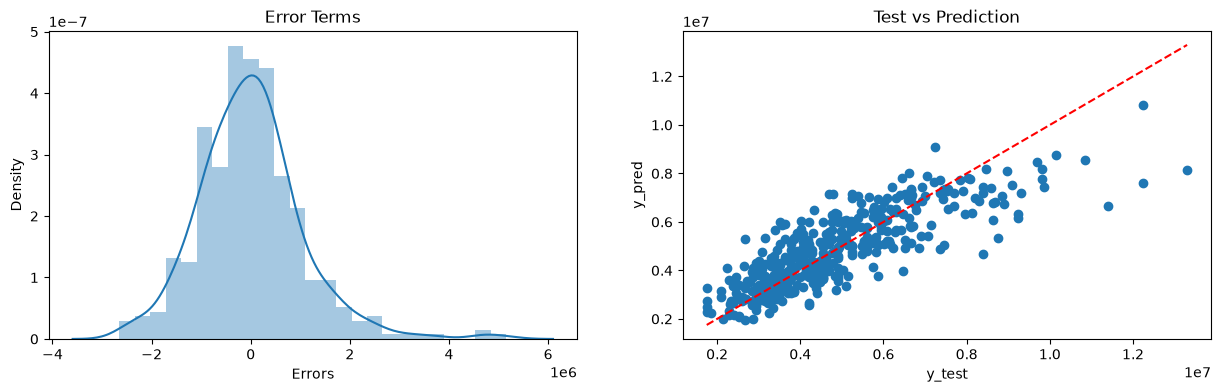

In [47]:
# r2_score Measures how much variation in the target is explained by the model.
"""
1.0  → perfect
0    → no improvement over predicting the mean
< 0  → worse than the mean baseline
"""
from sklearn.metrics import r2_score, mean_squared_error

# np.zeros([5,8]) Creates: 5 rows × 8 columns
Model_Evaluation_Comparison_Matrix = pd.DataFrame(
    np.zeros([5,8]),
    columns=[
        'Train-R2','Test-R2',
        'Train-RSS','Test-RSS',
        'Train-MSE','Test-MSE',
        'Train-RMSE','Test-RMSE'
    ]
)

# Train_X_std.nunique() Counts the number of unique values in every column.
# Train_X_std.loc[:, condition] keeps only columns satisfying that condition.
rc=np.random.choice(Train_X_std.loc[:,Train_X_std.nunique()>=50].columns.values,1,replace=False)

# define the evaluation function
def Evaluate(n, pred1,pred2):
    #Plotting predicted predicteds alongside the actual datapoints 
    plt.figure(figsize=[15,6])
    for e,i in enumerate(rc):
        plt.subplot(2,3,e+1)

        # X-axis → selected feature , Y-axis → actual house price
        plt.scatter(y=Train_Y, x=Train_X_std[i], label='Actual')
        plt.scatter(y=pred1, x=Train_X_std[i], label='Prediction')
        plt.legend()
  

  #Evaluating the Multiple Linear Regression Model

    print('\n\n{}Training Set Metrics{}'.format('-'*20, '-'*20))

    # compares actual training prices vs predicted training prices
    print('\nR2-Score on Training set --->',round(r2_score(Train_Y, pred1),20))

    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Train_Y-pred1)),20))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Train_Y, pred1),20))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Train_Y, pred1)),20))

    print('\n{}Testing Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Testing set --->',round(r2_score(Test_Y, pred2),20))
    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Test_Y-pred2)),20))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Test_Y, pred2),20))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Test_Y, pred2)),20))
    print('\n{}Residual Plots{}'.format('-'*20, '-'*20))
    
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-R2']  = round(r2_score(Train_Y, pred1),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-R2']   = round(r2_score(Test_Y, pred2),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-RSS'] = round(np.sum(np.square(Train_Y-pred1)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-RSS']  = round(np.sum(np.square(Test_Y-pred2)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-MSE'] = round(mean_squared_error(Train_Y, pred1),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-MSE']  = round(mean_squared_error(Test_Y, pred2),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-RMSE']= round(np.sqrt(mean_squared_error(Train_Y, pred1)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-RMSE'] = round(np.sqrt(mean_squared_error(Test_Y, pred2)),20)

    # Plotting y_test and y_pred to understand the spread.
    plt.figure(figsize=[15,4])

    plt.subplot(1,2,1)
    sns.distplot((Train_Y - pred1))
    plt.title('Error Terms')          
    plt.xlabel('Errors') 

    plt.subplot(1,2,2)
    plt.scatter(Train_Y,pred1)
    plt.plot([Train_Y.min(),Train_Y.max()],[Train_Y.min(),Train_Y.max()], 'r--')
    plt.title('Test vs Prediction')         
    plt.xlabel('y_test')                       
    plt.ylabel('y_pred')    


MLR = LinearRegression().fit(Train_X_std,Train_Y)
pred1 = MLR.predict(Train_X_std)
pred2 = MLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Multiple Linear Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(0, pred1, pred2) 

<<<----------------------------------- Evaluating Ridge Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 523109.95193922   66116.64775464  571341.38886287  357741.5667533
  575124.37673332  384897.45745525  277737.762919    847855.38320599
  845077.64065092  208377.3327589   604469.53802638 -101979.02160813
 -427196.80240469]
The Intercept of the Regresion Model was found to be  3877047.001651504


--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.6781434049395403
Residual Sum of Squares (RSS) on Training set  ---> 488147454198748.5
Mean Squared Error (MSE) on Training set       ---> 1119604252749.423
Root Mean Squared Error (RMSE) on Training set ---> 1058113.5349051268

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.6811803505574876
Residual Sum of Squares (RSS) on Training set  ---> 122654196031545.55
Mean Squared Error (MSE) on T

C:\Users\piyus\AppData\Local\Temp\ipykernel_2356\2541320826.py:68: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Train_Y - pred1))


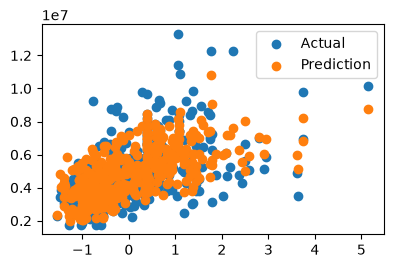

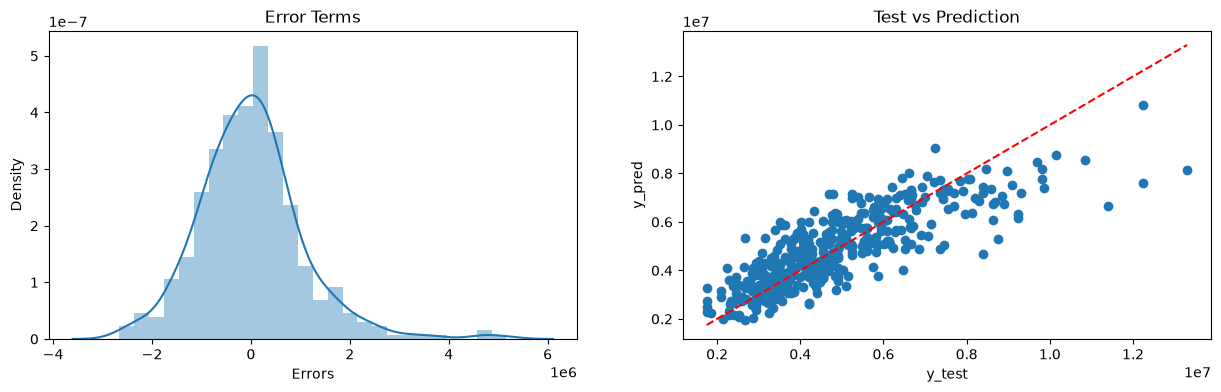

In [48]:
from sklearn.linear_model import Ridge

RLR = Ridge().fit(Train_X_std,Train_Y)
pred1 = RLR.predict(Train_X_std)
pred2 = RLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Ridge Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(1, pred1, pred2)

<<<----------------------------------- Evaluating Elastic-Net Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 523109.95193922   66116.64775464  571341.38886287  357741.5667533
  575124.37673332  384897.45745525  277737.762919    847855.38320599
  845077.64065092  208377.3327589   604469.53802638 -101979.02160813
 -427196.80240469]
The Intercept of the Regresion Model was found to be  3877047.001651504


--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.6004785762081208
Residual Sum of Squares (RSS) on Training set  ---> 605938697279856.0
Mean Squared Error (MSE) on Training set       ---> 1389767654311.5964
Root Mean Squared Error (RMSE) on Training set ---> 1178884.0716167118

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.6304354960991346
Residual Sum of Squares (RSS) on Training set  ---> 142176422272025.0
Mean Squared Error (MSE

C:\Users\piyus\AppData\Local\Temp\ipykernel_2356\2541320826.py:68: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((Train_Y - pred1))


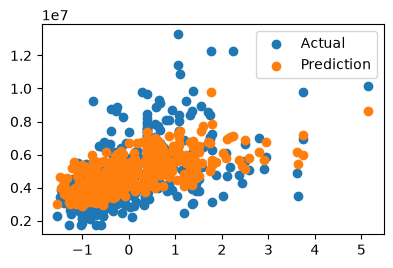

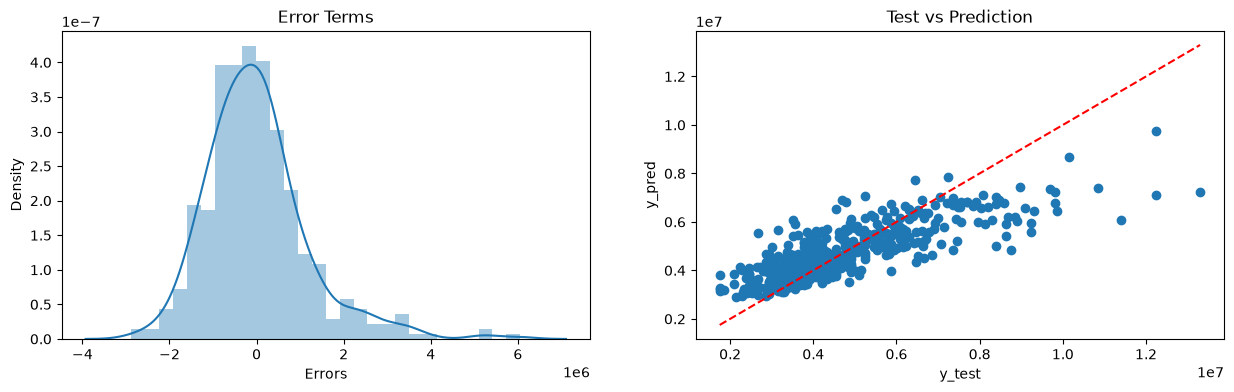

In [49]:
#Creating a ElasticNet Regression model

from sklearn.linear_model import ElasticNet

ENR = ElasticNet().fit(Train_X_std,Train_Y)
pred1 = ENR.predict(Train_X_std)
pred2 = ENR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Elastic-Net Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(3, pred1, pred2)

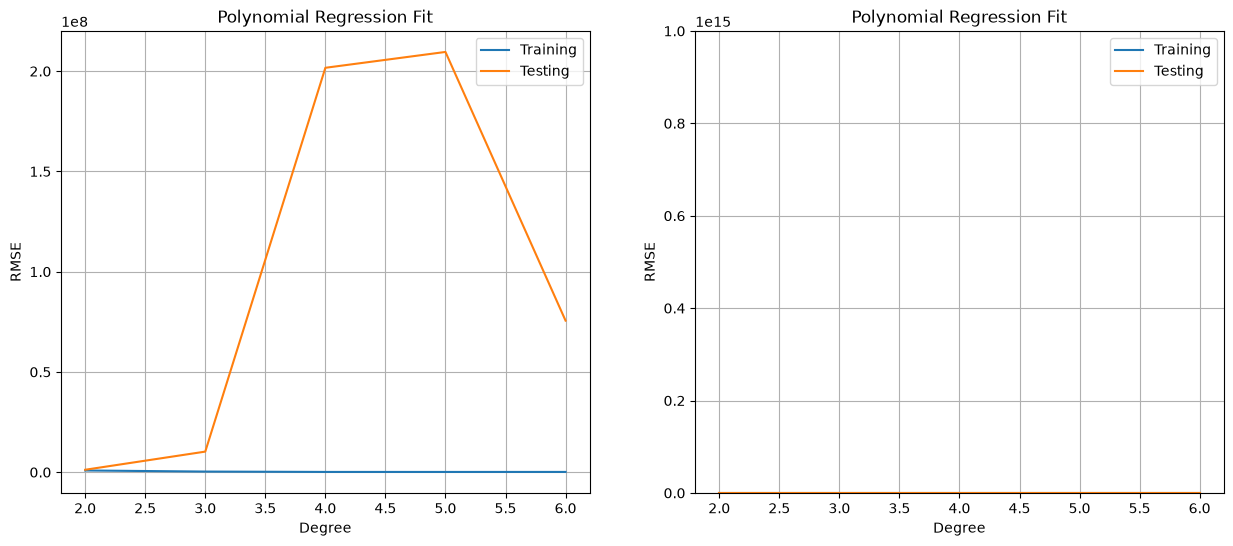

In [50]:
#Checking polynomial regression performance on various degrees

Trr=[]; Tss=[]
n_degree=7

for i in range(2,n_degree):
    #print(f'{i} Degree')
    poly_reg = PolynomialFeatures(degree=i)
    X_poly = poly_reg.fit_transform(Train_X_std)
    X_poly1 = poly_reg.fit_transform(Test_X_std)
    LR = LinearRegression()
    LR.fit(X_poly, Train_Y)
    
    pred1 = LR.predict(X_poly)
    Trr.append(np.sqrt(mean_squared_error(Train_Y, pred1)))
    
    pred2 = LR.predict(X_poly1)
    Tss.append(np.sqrt(mean_squared_error(Test_Y, pred2)))

plt.figure(figsize=[15,6])
plt.subplot(1,2,1)
plt.plot(range(2,n_degree),Trr, label='Training')
plt.plot(range(2,n_degree),Tss, label='Testing')
#plt.plot([1,4],[1,4],'b--')
plt.title('Polynomial Regression Fit')
#plt.ylim([0,5])
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.grid()
plt.legend()


plt.subplot(1,2,2)
plt.plot(range(2,n_degree),Trr, label='Training')
plt.plot(range(2,n_degree),Tss, label='Testing')
plt.title('Polynomial Regression Fit')
plt.ylim([0,1e15])
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.grid()
plt.legend()